In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import odeint



In [2]:

def Kerr_system(N, Delta, K, Epsilon):
    a = destroy(N) 
    """
Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa 
        Lindbladiano: del sistema para un oscilador de Kerr 
        Expect_ops: np.array[] de los operadores que se requiera su valor esperado

     Hamiltoniano Kerr Oscillator de acuerdo al paper de Zhang2021:
         Detuning         (omega_d)
         No linealidad de Keer  (U)
         Squeezing              (G)
    """

    H = (
        - Delta*a.dag()*a               
        +  0.5*K* a.dag()*a.dag() *a*a       
        + 0.25*Epsilon* (a.dag()*a.dag() + a*a) 
        )
    
    return H
    
def Kerr_Diag(N, Delta, K, Epsilon, Jump_ops):
 
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa
        Eigenvalores del sistema.
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)
    L = liouvillian(H, Jump_ops)
    eigs = L.eigenenergies()

    return eigs

def Kerr_evo(N, Delta, K, Epsilon, Jump_ops, Expected_ops):
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    
    Regresa 
        Estados evolucionados para cada paso de tiempo
        Evolución del valor de expectacion de los Expect_ops
    '''
    t = linspace(0,10, 100) # 100 pasos de tiempo entre 0 - 10
    H = Kerr_system(N, Delta, K, Epsilon)

    init_rho = coherent(N, 1)
    evo = mesolve(H, init_rho, t, Jump_ops, Expect_ops)

    return evo 

    



# Grafica k$\langle n\rangle$ vs $\varepsilon$
Observamos la transición de fase para perdida de un fotón, sucede cuando $\varepsilon = \gamma $

In [19]:
# -----------------------Parametros-------------------------------
N = [20,40,60,80,100]              # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75]     # Interaction, Kerr NL
    )             
Delta = 0                         # Detuning 
epsi_list = np.linspace(0.01,2,100)    # Squeezing


"""
Calcular valor esperado de diferentes N para diferentes epsilon y diferentes K, en el ss
"""
# Pre-asignar array 3D para máxima eficiencia
n_1values = np.zeros((len(N), len(K_list), len(epsi_list)))

for i, d in enumerate(N):
    a = destroy(d)
    n = a.dag() * a
    salto = [np.sqrt(g) * a]
    
    for j, K in enumerate(K_list):
        print(f"d={d}, K={K:.4f}" + '\n')
        
        for k, e in enumerate(epsi_list):
            H = Kerr_system(d, Delta, K, e)
            rho_ss = steadystate(H, salto)    
            n_ss = expect(n, rho_ss)
            
            # Guardar directamente en el array
            n_1values[i, j, k] = n_ss
            
            # Imprimir solo primeros 5
            if k < 5:
                print(
                    rf"eps={e:.3f}, "
                    f"<n>={n_ss:.4f}, "
                    f"Tr={rho_ss.tr():.8f}, "
                    f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
                    f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
                    )
        print('\n')
'''
Acceso fácil y eficiente:
    n_1values[0, 0, :]  # d=2 (índice 0), K=1/15 (índice 0)
    n_1values[1, 3, :]  # d=3 (índice 1), K=1/75 (índice 3)

Operaciones vectorizadas rápidas:
    np.mean(n_1values, axis=1)   Promedio sobre K para cada d
    np.max(n_1values, axis=2)   Máximo sobre epsilon
 '''       
print('-----------------------------------Finalizado------------------------------------')


d=20, K=0.0667

eps=0.010, <n>=0.0000, Tr=1.00000000, Tr^2=0.99995022, minEig=-1.476e-17
eps=0.030, <n>=0.0005, Tr=1.00000000, Tr^2=0.99954888, minEig=-2.360e-17
eps=0.050, <n>=0.0013, Tr=1.00000000, Tr^2=0.99874478, minEig=-5.681e-20
eps=0.070, <n>=0.0025, Tr=1.00000000, Tr^2=0.99753707, minEig=-1.123e-17
eps=0.090, <n>=0.0041, Tr=1.00000000, Tr^2=0.99592452, minEig=-2.014e-17


d=20, K=0.0333

eps=0.010, <n>=0.0000, Tr=1.00000000, Tr^2=0.99995005, minEig=-3.898e-18
eps=0.030, <n>=0.0005, Tr=1.00000000, Tr^2=0.99954737, minEig=3.707e-31
eps=0.050, <n>=0.0013, Tr=1.00000000, Tr^2=0.99874051, minEig=-6.961e-18
eps=0.070, <n>=0.0025, Tr=1.00000000, Tr^2=0.99752854, minEig=-1.034e-20
eps=0.090, <n>=0.0041, Tr=1.00000000, Tr^2=0.99591003, minEig=-2.074e-20


d=20, K=0.0167

eps=0.010, <n>=0.0000, Tr=1.00000000, Tr^2=0.99995001, minEig=-2.177e-27
eps=0.030, <n>=0.0005, Tr=1.00000000, Tr^2=0.99954699, minEig=-5.762e-18
eps=0.050, <n>=0.0013, Tr=1.00000000, Tr^2=0.99873944, minEig=-6.131e-18


Haciendo MF obtenemos las siguientes ecuaciones i.e. $\langle \hat a \rangle = \alpha$ y $\langle \hat a^\dagger\hat a^2\rangle = \langle\hat a^\dagger \rangle\langle \hat a \rangle^2$:
$$
\frac{d\alpha}{dt} = \left(\Delta - K|\alpha|^2 +i \frac{\gamma}{2}\right)\alpha - \frac{\varepsilon}{2}\alpha^*
$$
El estado estacionario (ss) sucede cuando $\frac{d\alpha}{dt}=0$, que es lo mismo que decir que $\frac{d\rho(t)}{dt} = 0 = \mathcal L [\rho, L_k]$ i.e. el eigenvalor 0 del Lindbladiano. con $\alpha = \sqrt{n} e^{i\theta}$, donde n es el # de fotones, resolviendo para n 
$$
n_{ss} = \frac{1}{K} \left[\Delta \mp \frac{1}{2}\sqrt{|\varepsilon|^2 - \gamma^2}\right]
$$
En este caso particular y considerando $n\leq0$, llegando una expresion parecida a $\quad y = \frac{1}{2} \sqrt{x^2 - 1}$
$$
Kn_{ss} = \frac{1}{2} \sqrt{|\varepsilon|^2 - \gamma^2}
$$


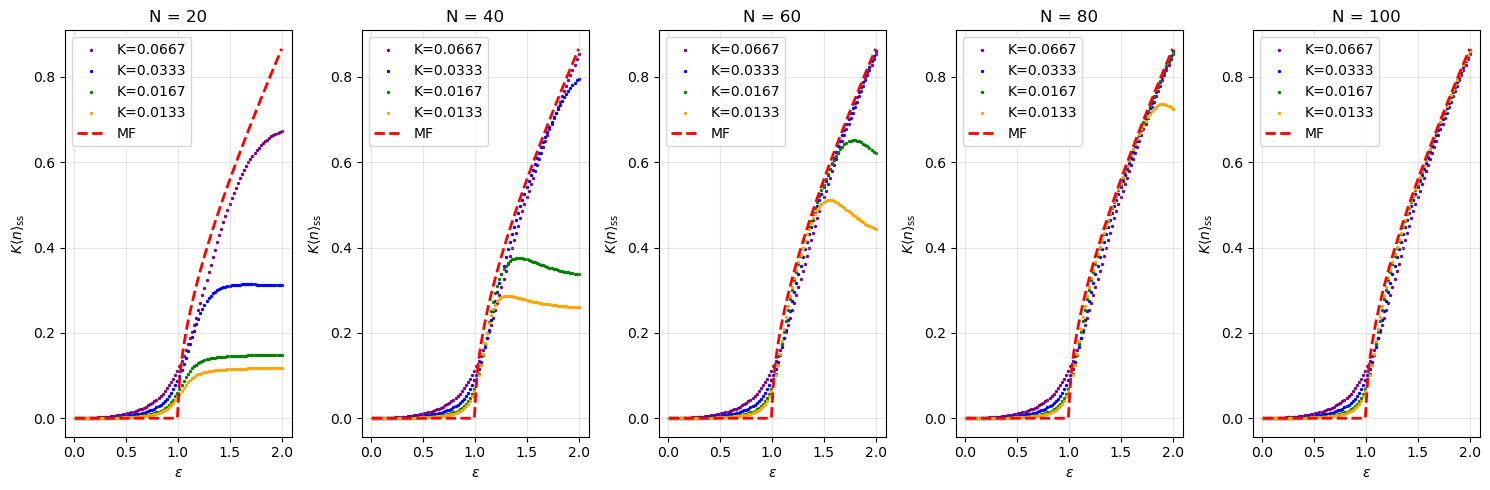

<Figure size 640x480 with 0 Axes>

In [29]:
#---------- Mean Field -------------------------------------

r = np.clip(epsi_list**2 - g**2, a_min=0, a_max=None)
n_mf = 0.5 * np.sqrt(r)
#------------------------------------------------------------
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_1values
"""
fig, axes = plt.subplots(1, len(N), figsize=(15, 5))
colors = ['purple', 'blue', 'green', 'orange']

for idx_d, (ax, d) in enumerate(zip(axes, N)):
    for i, K in enumerate(K_list):
        ax.scatter(epsi_list, K * n_1values[idx_d, i, :], 
                  c=colors[i % len(colors)], s=2, 
                  label=f"K={K:.4f}"
                  )
    
    ax.plot(epsi_list, n_mf, c='red', linewidth=2, linestyle='--', label='MF')
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$K\langle n\rangle_{\rm ss}$")
    ax.set_title(f"N = {d}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('1photon/n_vs_epsilon_1photon.pdf')


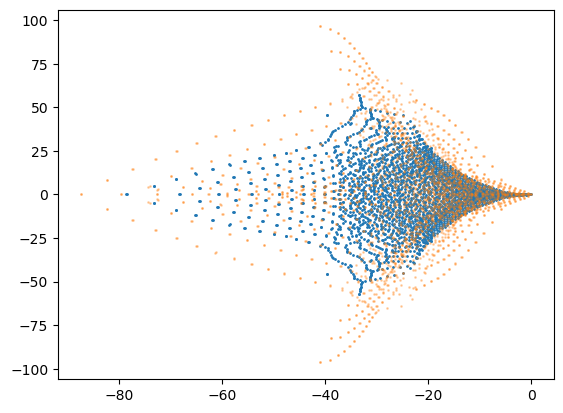

In [18]:
j = [destroy(50)]

xy = Kerr_Diag(50, 0, 1/30, 0.5, j)
plt.scatter(np.real(xy), np.imag(xy),s=1)
xy = Kerr_Diag(50, 0, 1/30, 1.5, j)
plt.scatter(np.real(xy), np.imag(xy),s=1, alpha=0.3)
plt.show()

Cargando resultados desde caché...


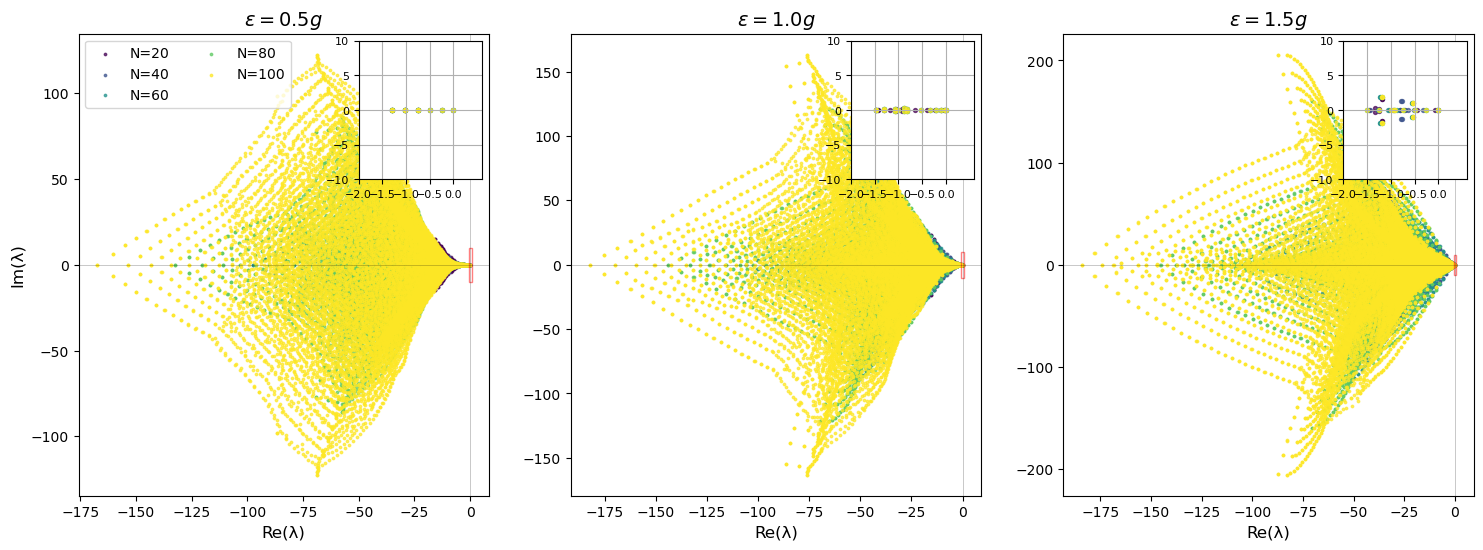

In [22]:
import time
import pickle
import os

# Parámetros
N_values = [20, 40, 60, 80, 100]
g = 1.0
k = 1/60
Delta = 0
epsilon_values = [0.5*g, 1.0*g, 1.5*g]
epsilon_labels = [r'$\epsilon = 0.5g$', r'$\epsilon = 1.0g$', r'$\epsilon = 1.5g$']

# Archivo de caché
cache_folder = '1photon'  # Nombre de la carpeta
cache_file = os.path.join(cache_folder, 'eigenvalues_cache.pkl')  # Ruta completa

# Intentar cargar desde caché
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    with open(cache_file, 'rb') as f:
        results_cache = pickle.load(f)
else:
    results_cache = {}
    print("Calculando eigenvalores (esto puede tomar un momento)...")
    start_time = time.time()
    
    for eps in epsilon_values:
        for N in N_values:
            key = f"N{N}_eps{eps}"
            salto = [np.sqrt(g) * destroy(N)]
            eigs = Kerr_Diag(N, Delta, k, eps, salto)
            results_cache[key] = eigs
            print(f"  N={N}, eps={eps/g:.1f}g - listo")
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en caché
    with open(cache_file, 'wb') as f:
        pickle.dump(results_cache, f)

# Crear figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(N_values)))

for idx, (eps, label) in enumerate(zip(epsilon_values, epsilon_labels)):
    ax = axes[idx]
    axins = inset_axes(ax, width="30%", height="30%", loc='upper right')
    
    for i, N in enumerate(N_values):
        # Obtener eigenvalores del caché
        key = f"N{N}_eps{eps}"
        eigs = results_cache[key]
        
        X = np.real(eigs)
        Y = np.imag(eigs)
        
        ax.scatter(X, Y, s=3, c=[colors[i]], alpha=0.7, 
                  label=f'N={N}' if idx == 0 else "", rasterized=True)
        
        mask = (X > -1.5) & (X < 1.5) & (Y > -15) & (Y < 15)
        if np.any(mask):
            axins.scatter(X[mask], Y[mask], s=8, c=[colors[i]], alpha=0.7)
    
    ax.set_title(label, fontsize=14)
    ax.set_xlabel('Re(λ)', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Im(λ)', fontsize=12)
    
    ax.axhline(0, color='black', lw=0.5, alpha=0.3)
    ax.axvline(0, color='black', lw=0.5, alpha=0.3)
#    ax.set_xlim([-20, 5])
#    ax.set_ylim([-50, 50])
    
    axins.set_xlim(-2, 0.6)
    axins.set_ylim(-10, 10)
    axins.grid(0.5)
    axins.tick_params(axis='both', labelsize=8)
    axins.set_xticks([-2 , -1.5, -1, -0.5,0])
    axins.set_yticks([-10, -5, 0, 5, 10])
    
    # Indicador de zona de zoom
    from matplotlib.patches import Rectangle
    rect = Rectangle((-0.6, -10), 1.2, 20, 
                     linewidth=1, edgecolor='red', facecolor='none', alpha=0.5)
    ax.add_patch(rect)

axes[0].legend(loc='upper left', fontsize=10, ncol=2)
plt.savefig('eigsKerr_3_epsilon.pdf', dpi=300, bbox_inches='tight')
plt.show()